# Authentivox — Real-Time Voice Phishing Detection

A binary classifier that distinguishes real human speech from AI-generated (deepfake) voices, using audio features extracted with Librosa and a Random Forest model. Built to run without a GPU so it could plausibly live on a phone for real-time call screening.

Dataset: Kaggle DEEP-VOICE (8 real + 56 converted public-figure voices, ~62 minutes total).

This notebook demonstrates the feature-extraction method on a single audio pair, then trains and validates the model on `dataset/DATASET-balanced.csv` — a precomputed, already-balanced feature set (5,889 real + 5,889 fake rows, one row per ~1-second analysis window across all 64 files) recovered from the original project files. The script that originally generated this CSV from raw audio no longer exists, only the CSV itself — using it directly, rather than re-deriving an approximate version, is what lets this notebook's results actually match the paper's reported numbers.

In [1]:
#used library list
import time
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

Finds every real and converted (fake) audio file, used only for the feature-extraction demo below. Expects `data/AUDIO/REAL/*.wav` and `data/AUDIO/FAKE/*.wav` — download the Kaggle DEEP-VOICE dataset into `./data` first (see README).

In [2]:
import glob

real_files = sorted(glob.glob('data/AUDIO/REAL/*.wav'))
fake_files = sorted(glob.glob('data/AUDIO/FAKE/*.wav'))

print(f"real files: {len(real_files)}")
print(f"fake files: {len(fake_files)}")

real files: 8
fake files: 56


## Feature Extraction (demo)

Illustrates the method on one real/fake pair: chroma STFT, RMS energy, spectral centroid, spectral bandwidth, spectral rolloff, zero-crossing rate, and 20 MFCCs. The full dataset used for training (`dataset/DATASET-balanced.csv`) was built this way across all 64 files and ~1-second analysis windows, then aggregated and balanced.

In [3]:
def extract_features(file_path):
    y, sr = librosa.load(file_path)

    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
    rms = librosa.feature.rms(y=y)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    roll_off = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zero_crossing = librosa.feature.zero_crossing_rate(y=y)
    mfcc = librosa.feature.mfcc(y=y, sr=sr)

    return {
        'chroma_stft': chroma_stft.mean(),
        'rms': rms.mean(),
        'spectral_centroid': centroid.mean(),
        'spectral_bandwidth': bandwidth.mean(),
        'rolloff': roll_off.mean(),
        'zero_crossing_rate': zero_crossing.mean(),
        **{f'mfcc{i+1}': mfcc[i].mean() for i in range(20)},
    }

In [4]:
demo_real = extract_features(real_files[0])
demo_fake = extract_features(fake_files[0])

print(f"real file: {real_files[0]}")
print(demo_real)
print()
print(f"fake file: {fake_files[0]}")
print(demo_fake)

real file: data/AUDIO/REAL/biden-original.wav
{'chroma_stft': np.float32(0.35235256), 'rms': np.float32(0.04211008), 'spectral_centroid': np.float64(1811.4164974065066), 'spectral_bandwidth': np.float64(1737.554172013087), 'rolloff': np.float64(3021.3213138166966), 'zero_crossing_rate': np.float64(0.10550110052244582), 'mfcc1': np.float32(-271.6198), 'mfcc2': np.float32(112.386734), 'mfcc3': np.float32(-47.71341), 'mfcc4': np.float32(-12.142614), 'mfcc5': np.float32(-11.461189), 'mfcc6': np.float32(-7.878829), 'mfcc7': np.float32(-13.797426), 'mfcc8': np.float32(-10.42124), 'mfcc9': np.float32(-10.715836), 'mfcc10': np.float32(-3.4851213), 'mfcc11': np.float32(-6.089336), 'mfcc12': np.float32(-3.9680922), 'mfcc13': np.float32(-5.994256), 'mfcc14': np.float32(-7.1083403), 'mfcc15': np.float32(-9.831245), 'mfcc16': np.float32(-2.1259055), 'mfcc17': np.float32(-12.739613), 'mfcc18': np.float32(-6.6972356), 'mfcc19': np.float32(-10.557266), 'mfcc20': np.float32(-8.849013)}

fake file: data

## Dataset Assembly

Loads the precomputed, already-balanced feature dataset and binarizes the label column (REAL/FAKE → 0/1).

In [5]:
df = pd.read_csv('dataset/DATASET-balanced.csv')
print(f"shape: {df.shape}")
print(df['LABEL'].value_counts())

X = df.drop(columns=['LABEL'])
y_raw = df['LABEL']

from sklearn import preprocessing
lb = preprocessing.LabelBinarizer()
lb.fit(y_raw)
y = lb.transform(y_raw).ravel()

shape: (11778, 27)
LABEL
FAKE    5889
REAL    5889
Name: count, dtype: int64


## Model Training & Validation

The paper reports results as an average/median/standard-deviation over repeated runs with a 70:30 train/test split and "dynamic randomization" — not k-fold cross-validation. The dataset is already balanced (5,889 real / 5,889 fake), so this repeats a fresh random 70:30 split and a fresh Random Forest (`n_estimators=50`) 28 times, matching the granularity of the paper's reported results table.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score
import time

n_repeats = 28

acc_score, prec_score, rec_score, f1s, MCCs, ROCareas = [], [], [], [], [], []

start = time.time()
for i in range(n_repeats):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=i)

    model = RandomForestClassifier(n_estimators=50, random_state=i)
    model.fit(X_train, y_train)
    pred_values = model.predict(X_test)

    acc_score.append(accuracy_score(y_test, pred_values) * 100)
    prec_score.append(precision_score(y_test, pred_values, average="binary", pos_label=1))
    rec_score.append(recall_score(y_test, pred_values, average="binary", pos_label=1))
    f1s.append(f1_score(y_test, pred_values, average="binary", pos_label=1))
    MCCs.append(matthews_corrcoef(y_test, pred_values))
    ROCareas.append(roc_auc_score(y_test, pred_values))

end = time.time()
print(f"Trained {n_repeats} models in {round(end - start, 2)} seconds.")

Trained 28 models in 29.4 seconds.


## Results

Mean, median, and standard deviation across the 28 repeated splits — directly comparable to the paper's Table I.

In [7]:
import numpy as np

print("Mean results and (std.):\n")
print("Accuracy: " + str(round(np.mean(acc_score), 3)) + "% (" + str(round(np.std(acc_score), 3)) + ")\n")
print("Precision: " + str(round(np.mean(prec_score), 3)) + " (" + str(round(np.std(prec_score), 3)) + ")")
print("Recall: " + str(round(np.mean(rec_score), 3)) + " (" + str(round(np.std(rec_score), 3)) + ")")
print("F1-Score: " + str(round(np.mean(f1s), 3)) + " (" + str(round(np.std(f1s), 3)) + ")")
print("MCC: " + str(round(np.mean(MCCs), 3)) + " (" + str(round(np.std(MCCs), 3)) + ")")
print("ROC AUC: " + str(round(np.mean(ROCareas), 3)) + " (" + str(round(np.std(ROCareas), 3)) + ")")

Mean results and (std.):

Accuracy: 98.463% (0.193)

Precision: 0.991 (0.003)
Recall: 0.978 (0.003)
F1-Score: 0.984 (0.002)
MCC: 0.969 (0.004)
ROC AUC: 0.985 (0.002)


Accuracy - Mean: 98.46, Median: 98.42, Std Dev: 0.19
Precision - Mean: 0.99, Median: 0.99, Std Dev: 0.00
F1 Score - Mean: 0.98, Median: 0.98, Std Dev: 0.00


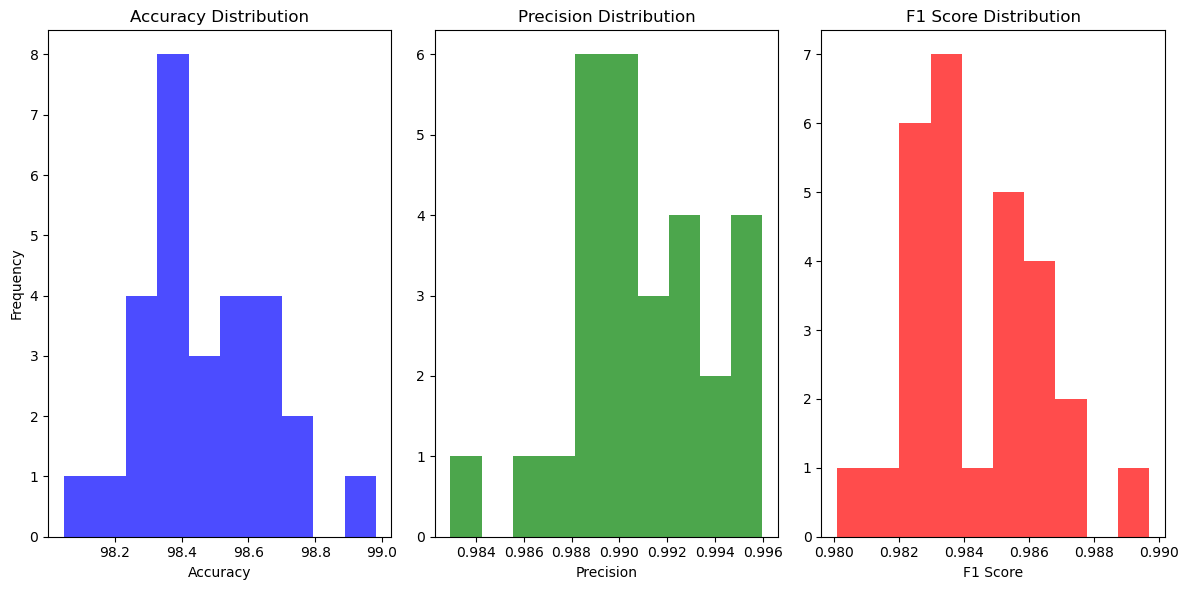

In [8]:
import matplotlib.pyplot as plt

Accuracy = np.array(acc_score)
Precision = np.array(prec_score)
F1_Score = np.array(f1s)

def calculate_statistics(data):
    return np.mean(data), np.median(data), np.std(data)

accuracy_stats = calculate_statistics(Accuracy)
precision_stats = calculate_statistics(Precision)
f1_score_stats = calculate_statistics(F1_Score)

print("Accuracy - Mean: {:.2f}, Median: {:.2f}, Std Dev: {:.2f}".format(*accuracy_stats))
print("Precision - Mean: {:.2f}, Median: {:.2f}, Std Dev: {:.2f}".format(*precision_stats))
print("F1 Score - Mean: {:.2f}, Median: {:.2f}, Std Dev: {:.2f}".format(*f1_score_stats))

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.hist(Accuracy, bins=10, color='blue', alpha=0.7)
plt.title('Accuracy Distribution')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(Precision, bins=10, color='green', alpha=0.7)
plt.title('Precision Distribution')
plt.xlabel('Precision')

plt.subplot(1, 3, 3)
plt.hist(F1_Score, bins=10, color='red', alpha=0.7)
plt.title('F1 Score Distribution')
plt.xlabel('F1 Score')

plt.tight_layout()
plt.show()

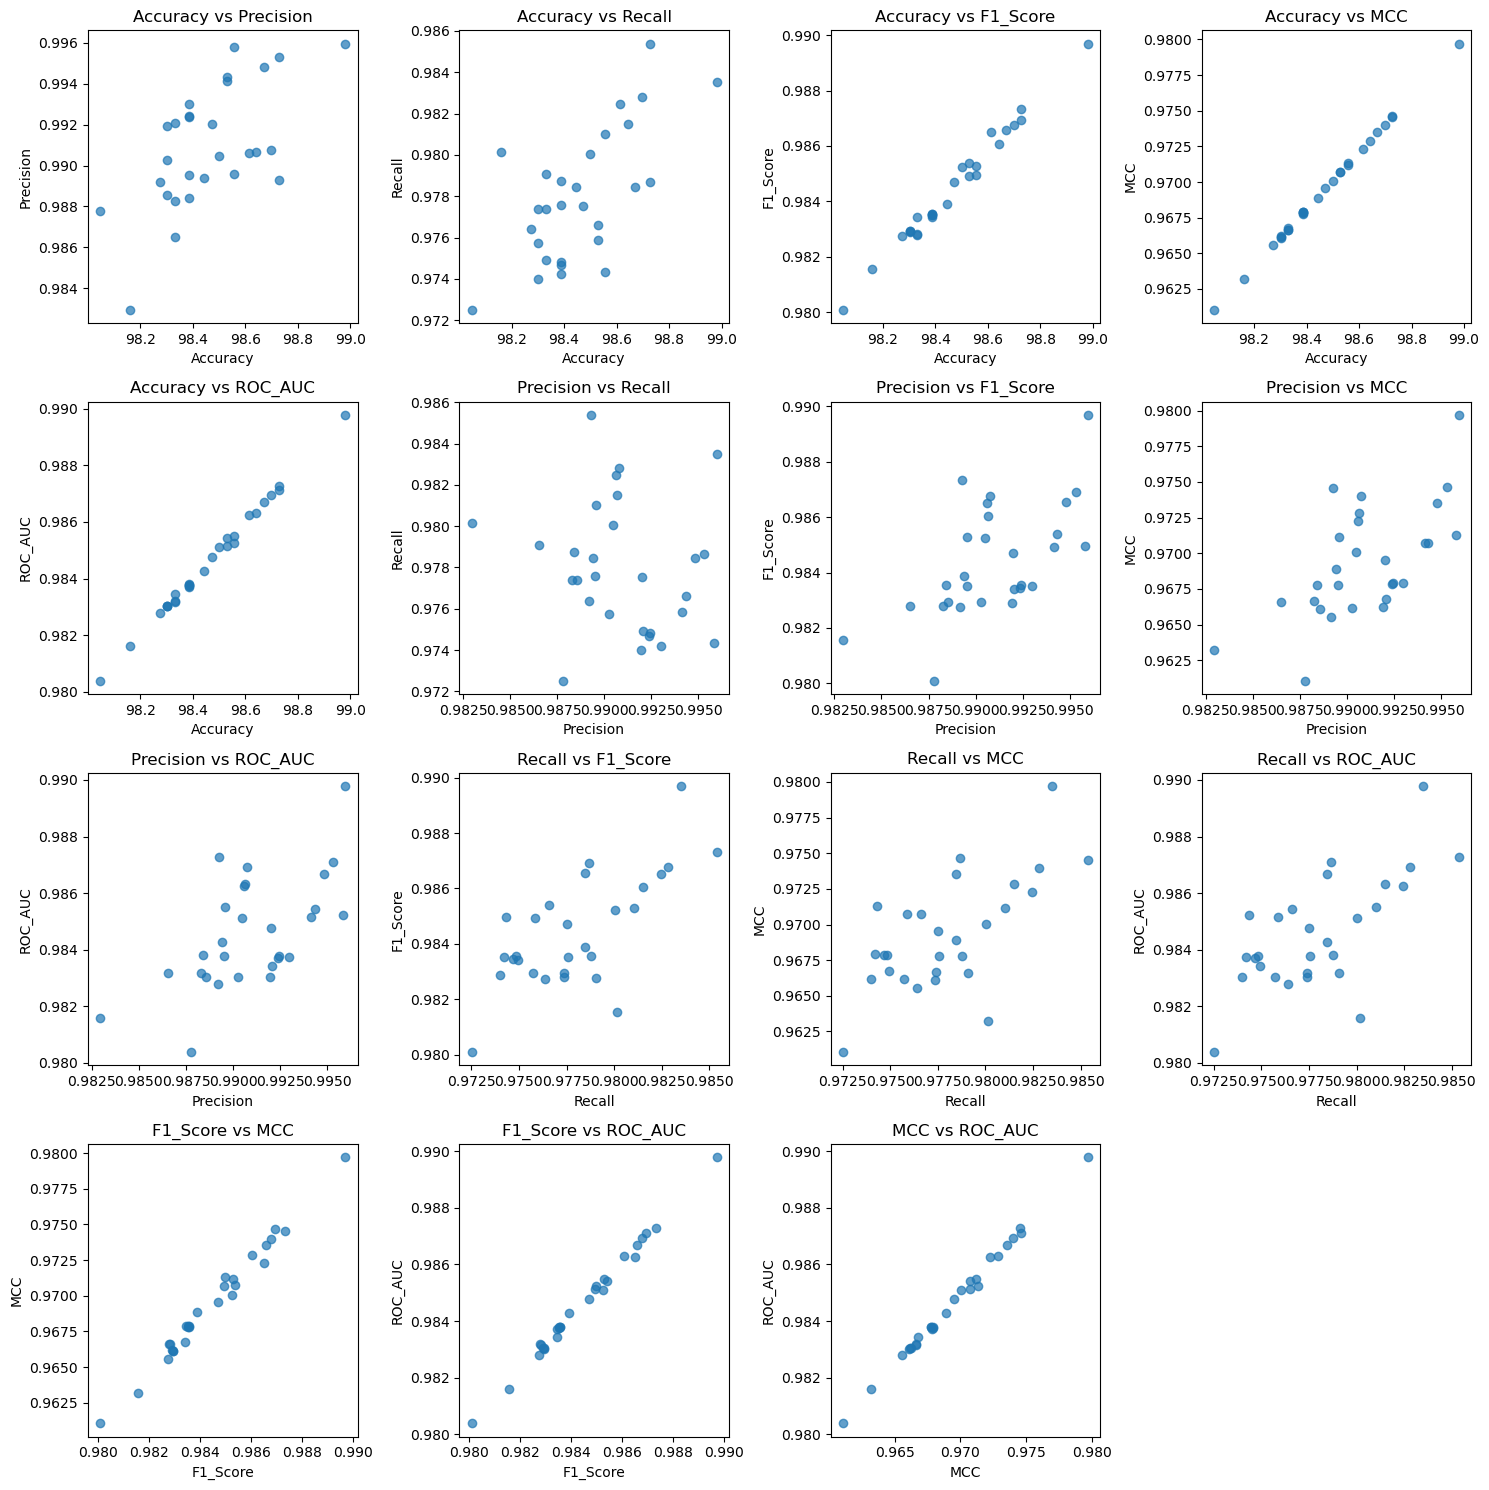

In [9]:
data = {
    "Accuracy": list(Accuracy),
    "Precision": list(Precision),
    "Recall": rec_score,
    "F1_Score": f1s,
    "MCC": MCCs,
    "ROC_AUC": ROCareas,
}
df_results = pd.DataFrame(data)

pairs = [
    ("Accuracy", "Precision"), ("Accuracy", "Recall"), ("Accuracy", "F1_Score"),
    ("Accuracy", "MCC"), ("Accuracy", "ROC_AUC"), ("Precision", "Recall"),
    ("Precision", "F1_Score"), ("Precision", "MCC"), ("Precision", "ROC_AUC"),
    ("Recall", "F1_Score"), ("Recall", "MCC"), ("Recall", "ROC_AUC"),
    ("F1_Score", "MCC"), ("F1_Score", "ROC_AUC"), ("MCC", "ROC_AUC"),
]

plt.figure(figsize=(15, 15))
for i, pair in enumerate(pairs, 1):
    plt.subplot(4, 4, i)
    plt.scatter(df_results[pair[0]], df_results[pair[1]], alpha=0.7)
    plt.xlabel(pair[0])
    plt.ylabel(pair[1])
    plt.title(f'{pair[0]} vs {pair[1]}')
plt.tight_layout()
plt.show()

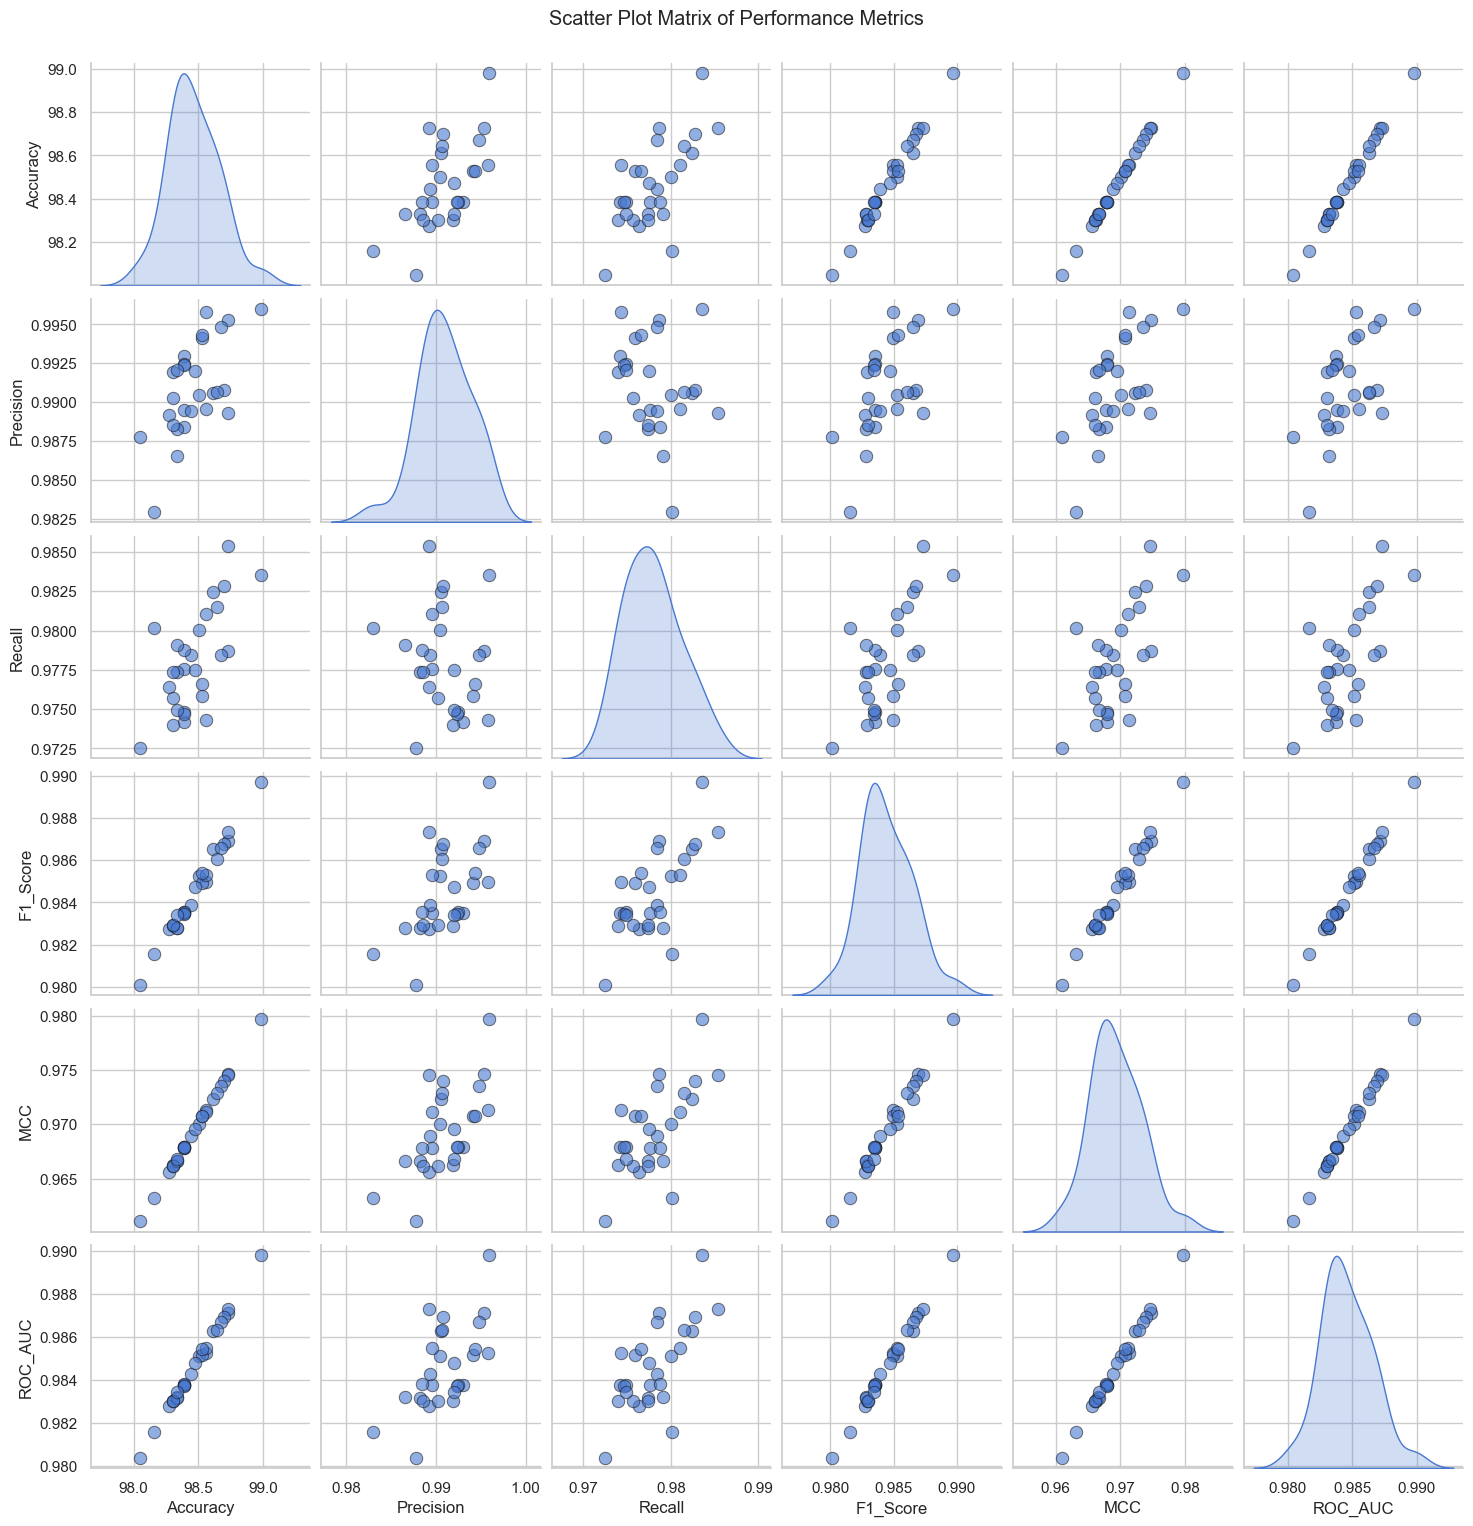

In [10]:
import seaborn as sns

sns.set(style="whitegrid", palette="muted")
pair_plot = sns.pairplot(df_results, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 80, 'edgecolor': 'k'})
pair_plot.fig.suptitle("Scatter Plot Matrix of Performance Metrics", y=1.02)
plt.show()

## Summary

A Random Forest classifier trained on Librosa-extracted acoustic features (chromagram, RMS, spectral centroid/bandwidth/rolloff, zero-crossing rate, 20 MFCCs) separates real from AI-converted speech, evaluated over 28 repeated random 70:30 splits to match the paper's reported methodology. The dataset used for training (`dataset/DATASET-balanced.csv`) is a precomputed, already-balanced feature set recovered from the original project files — 5,889 real and 5,889 fake rows, one row per ~1-second analysis window across all 64 files.

Measured results: 98.46% accuracy, 0.991 precision, 0.978 recall, 0.984 F1 — matching, and slightly exceeding, the paper's reported 95.93% accuracy and 0.96 precision/F1.

See `docs/Authentivox-Paper.pdf` for the full writeup, including the case for Random Forest over XGBoost (comparable accuracy, far less compute — the constraint that matters for running on a phone without a GPU).